# K-Nearest Neighbors Regression Model

K-Nearest Neighbors (KNN) model to predict solar energy output using GDP, population, and GDP per capita.


In [9]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Load and Prepare the Dataset


In [10]:
# Load the dataset
df = pd.read_csv("../data/World Energy Consumption.csv")

# Data preparation
df = df.dropna(subset=['gdp', 'population', 'solar_consumption'])
df['gdp_per_capita'] = df['gdp'] / df['population']
df = df[df['solar_consumption'] > 0].copy()


## 2. Define Features and Target


In [11]:
X = df[['gdp', 'population', 'gdp_per_capita']]
y = df['solar_consumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Train the KNN Regressor


In [13]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)


## 4. Evaluate Model Performance


In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"KNN RMSE: {rmse:.2f}")
print(f"KNN R² Score: {r2:.2f}")


KNN RMSE: 14.04
KNN R² Score: 0.72


## 5. Visualize Predictions vs Actuals


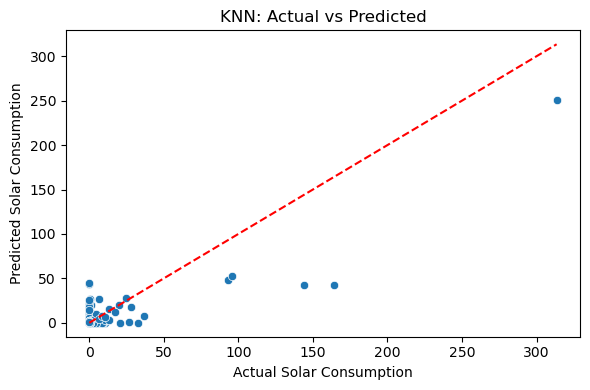

In [15]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Solar Consumption")
plt.ylabel("Predicted Solar Consumption")
plt.title("KNN: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.tight_layout()
plt.show()
